In [1]:
# Step 1: Import Libraries
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Conv2D, MaxPooling2D,
                                     Flatten, Dense, Dropout)
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import (classification_report,
                             confusion_matrix)
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully.")
print("TensorFlow version:", keras.__version__)

All libraries imported successfully.
TensorFlow version: 3.13.2


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Dataset loaded successfully.

Training images: (60000, 28, 28)
Testing images: (10000, 28, 28)
Image size: 28 x 28 pixels
Total classes: 10
Classes: [0 1 2 3 4 5 6 7 8 9]


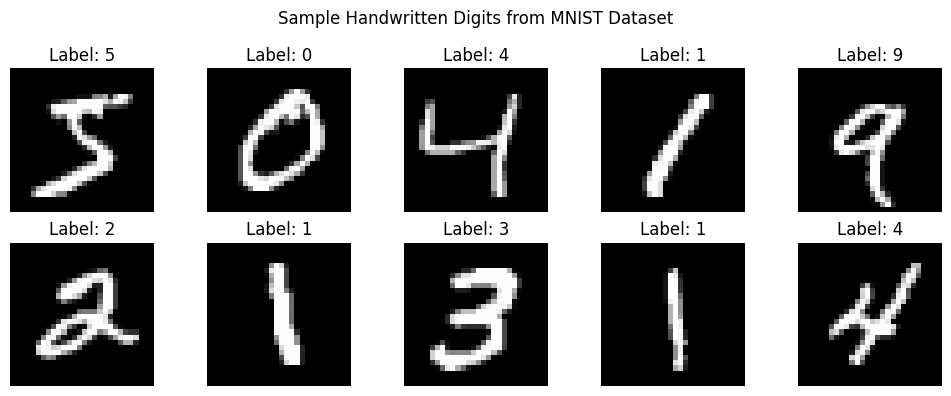


Sample images displayed successfully.


In [2]:
# Step 2: Load MNIST Dataset
from tensorflow.keras.datasets import mnist

# Load dataset
(X_train, y_train), (X_test, y_test) = mnist.load_data()

print("Dataset loaded successfully.")
print("\nTraining images:", X_train.shape)
print("Testing images:", X_test.shape)
print("Image size:", X_train.shape[1], "x", X_train.shape[2], "pixels")
print("Total classes:", len(np.unique(y_train)))
print("Classes:", np.unique(y_train))

# Visualize sample images
plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(X_train[i], cmap='gray')
    plt.title("Label: " + str(y_train[i]))
    plt.axis('off')
plt.suptitle('Sample Handwritten Digits from MNIST Dataset')
plt.tight_layout()
plt.show()

print("\nSample images displayed successfully.")

In [3]:
# Step 3: Preprocess the Data

# Normalize pixel values from 0-255 to 0-1
X_train = X_train / 255.0
X_test = X_test / 255.0

# Reshape images for CNN input (add channel dimension)
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

# Convert labels to categorical (one-hot encoding)
y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

print("Data preprocessing completed.")
print("\nTraining data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)
print("\nPixel values normalized from 0-255 to 0-1")
print("Labels converted to categorical format")
print("Data is ready for CNN model.")

Data preprocessing completed.

Training data shape: (60000, 28, 28, 1)
Testing data shape: (10000, 28, 28, 1)

Pixel values normalized from 0-255 to 0-1
Labels converted to categorical format
Data is ready for CNN model.


In [4]:
# Step 4: Build CNN Model

model = Sequential([
    # First Convolutional Layer
    Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    MaxPooling2D(2,2),

    # Second Convolutional Layer
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    # Third Convolutional Layer
    Conv2D(64, (3,3), activation='relu'),

    # Flatten and Dense Layers
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(10, activation='softmax')
])

model.summary()
print("\nCNN model built successfully.")

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 3, 3, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 130,890 (511.29 KB)

 Trainable params: 130,890 (511.29 KB)

 Non-trainable params: 0 (0.00 B)


CNN model built successfully.


In [5]:
# Step 5: Compile and Train the CNN Model

# Compile the model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Model compiled successfully.")
print("Starting training...")

# Train the model
history = model.fit(
    X_train, y_train_cat,
    epochs=10,
    batch_size=128,
    validation_split=0.1,
    verbose=1
)

print("\nModel training completed.")

Model compiled successfully.
Starting training...
Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 48s 108ms/step - accuracy: 0.8947 - loss: 0.3412 - val_accuracy: 0.9828 - val_loss: 0.0561
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 81s 106ms/step - accuracy: 0.9724 - loss: 0.0950 - val_accuracy: 0.9892 - val_loss: 0.0400
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 81s 104ms/step - accuracy: 0.9802 - loss: 0.0666 - val_accuracy: 0.9893 - val_loss: 0.0366
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 44s 104ms/step - accuracy: 0.9849 - loss: 0.0523 - val_accuracy: 0.9887 - val_loss: 0.0365
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 45s 106ms/step - accuracy: 0.9871 - loss: 0.0443 - val_accuracy: 0.9912 - val_loss: 0.0324
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 44s 104ms/step - accuracy: 0.9888 - loss: 0.0382 - val_accuracy: 0.9882 - val_loss: 0.0351
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 44s 104ms/step - accuracy: 0.9907 - loss: 0.0318 - val_accuracy: 0.9898 - val_loss: 0.0372
Epoch 8/10
422/422 ━━━━━━━━━━━━━━

Test Accuracy: 99.06 %
Test Loss: 0.0294


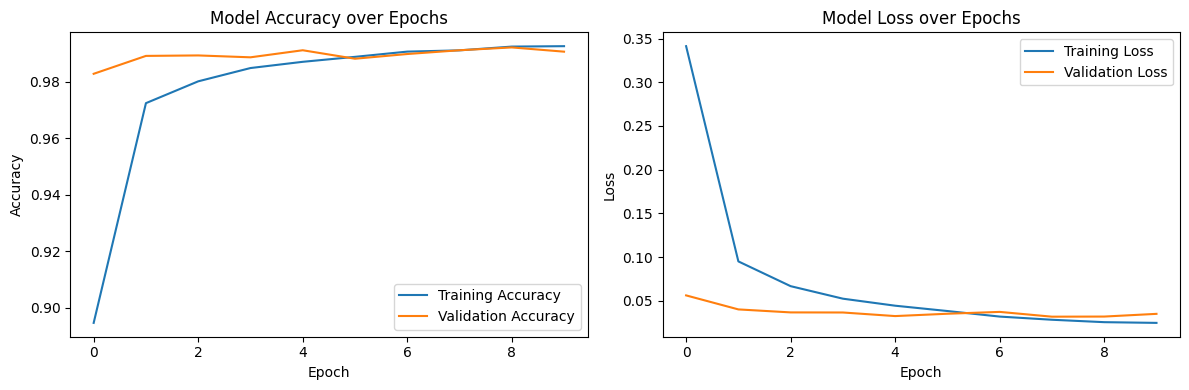

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step


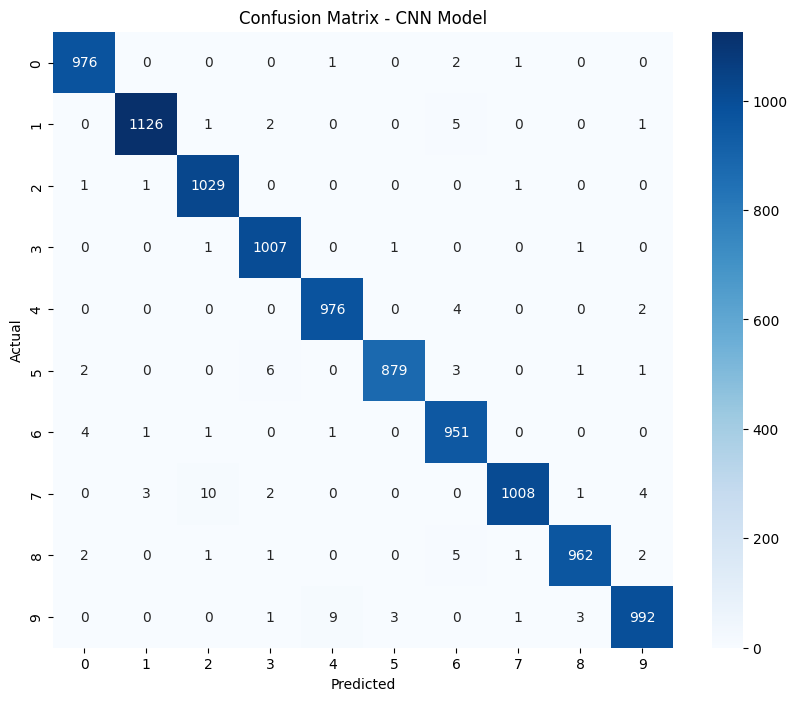


Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       980
           1       1.00      0.99      0.99      1135
           2       0.99      1.00      0.99      1032
           3       0.99      1.00      0.99      1010
           4       0.99      0.99      0.99       982
           5       1.00      0.99      0.99       892
           6       0.98      0.99      0.99       958
           7       1.00      0.98      0.99      1028
           8       0.99      0.99      0.99       974
           9       0.99      0.98      0.99      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



In [6]:
# Step 6: Evaluate Model and Visualize Results

# Test accuracy
test_loss, test_accuracy = model.evaluate(X_test, y_test_cat, verbose=0)
print("Test Accuracy:", round(test_accuracy*100, 2), "%")
print("Test Loss:", round(test_loss, 4))

# Training history plot
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

# Confusion Matrix
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_test, y_pred_classes)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - CNN Model')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

print("\nClassification Report:")
print(classification_report(y_test, y_pred_classes))

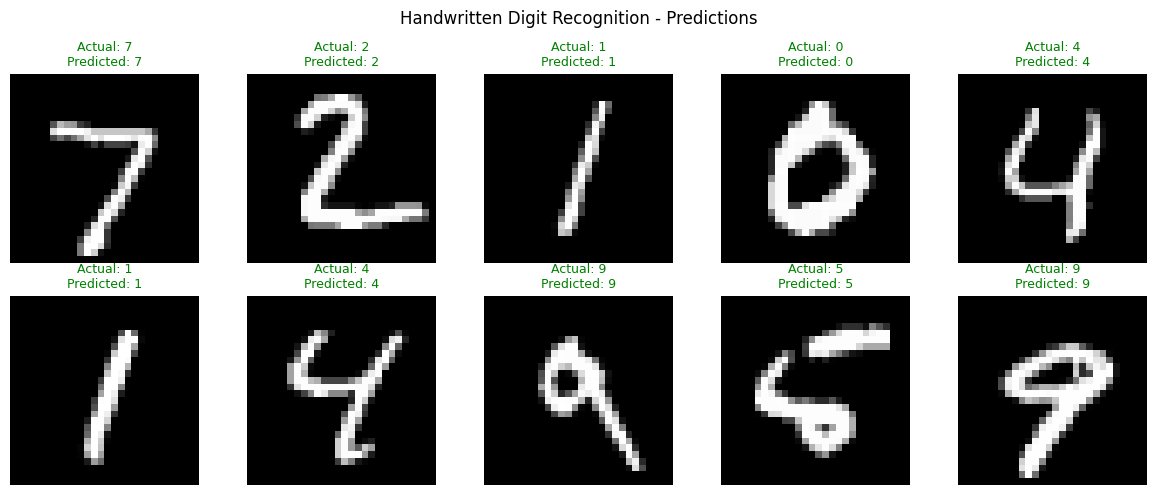

Task 3 - Handwritten Character Recognition - Completed
Final Model Accuracy: 99.06%


In [7]:
# Step 7: Predict on Sample Test Images

plt.figure(figsize=(12, 5))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(X_test[i].reshape(28, 28), cmap='gray')

    predicted = np.argmax(model.predict(X_test[i:i+1], verbose=0))
    actual = y_test[i]

    color = 'green' if predicted == actual else 'red'
    plt.title(f"Actual: {actual}\nPredicted: {predicted}",
              color=color, fontsize=9)
    plt.axis('off')

plt.suptitle('Handwritten Digit Recognition - Predictions')
plt.tight_layout()
plt.show()

print("Task 3 - Handwritten Character Recognition - Completed")
print("Final Model Accuracy: 99.06%")